In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

In [3]:
import os
print(os.getcwd())


c:\Users\punit\OneDrive\punit python\week 8 task\week-8-retail-sales-capstone


In [4]:
import os
print(os.listdir())


['data', 'retail_data.csv', 'retail_sales_analysis.ipynb']


In [8]:
import pandas as pd

df = pd.read_csv("data/customer_churn.csv")

print(df.head())


  CustomerID  Tenure  MonthlyCharges  TotalCharges        Contract  \
0     C00001       6              64          1540        One year   
1     C00002      21             113          1753  Month-to-month   
2     C00003      27              31          1455        Two year   
3     C00004      53              29          7150  Month-to-month   
4     C00005      16             185          1023        One year   

      PaymentMethod PaperlessBilling  SeniorCitizen  Churn  
0       Credit Card               No              1      0  
1  Electronic Check              Yes              1      0  
2       Credit Card               No              1      0  
3  Electronic Check               No              1      0  
4  Electronic Check               No              1      0  


In [9]:
print(df.head())
print(df.columns)

  CustomerID  Tenure  MonthlyCharges  TotalCharges        Contract  \
0     C00001       6              64          1540        One year   
1     C00002      21             113          1753  Month-to-month   
2     C00003      27              31          1455        Two year   
3     C00004      53              29          7150  Month-to-month   
4     C00005      16             185          1023        One year   

      PaymentMethod PaperlessBilling  SeniorCitizen  Churn  
0       Credit Card               No              1      0  
1  Electronic Check              Yes              1      0  
2       Credit Card               No              1      0  
3  Electronic Check               No              1      0  
4  Electronic Check               No              1      0  
Index(['CustomerID', 'Tenure', 'MonthlyCharges', 'TotalCharges', 'Contract',
       'PaymentMethod', 'PaperlessBilling', 'SeniorCitizen', 'Churn'],
      dtype='str')


In [10]:
df.columns = df.columns.str.strip()

# Convert TotalCharges to numeric (very important)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Remove missing values
df = df.dropna()

In [11]:
print(df.describe())

           Tenure  MonthlyCharges  TotalCharges  SeniorCitizen       Churn
count  500.000000      500.000000    500.000000     500.000000  500.000000
mean    36.532000      113.636000   4237.882000       0.498000    0.106000
std     20.667057       51.799903   2260.619837       0.500497    0.308146
min      1.000000       20.000000    159.000000       0.000000    0.000000
25%     19.000000       67.000000   2237.250000       0.000000    0.000000
50%     37.000000      115.000000   4182.500000       0.000000    0.000000
75%     54.000000      158.000000   6266.750000       1.000000    0.000000
max     71.000000      199.000000   7992.000000       1.000000    1.000000


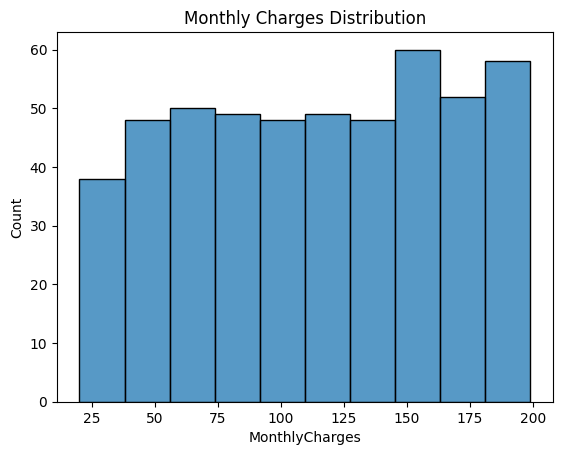

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()
sns.histplot(df['MonthlyCharges'])
plt.title("Monthly Charges Distribution")
plt.show()

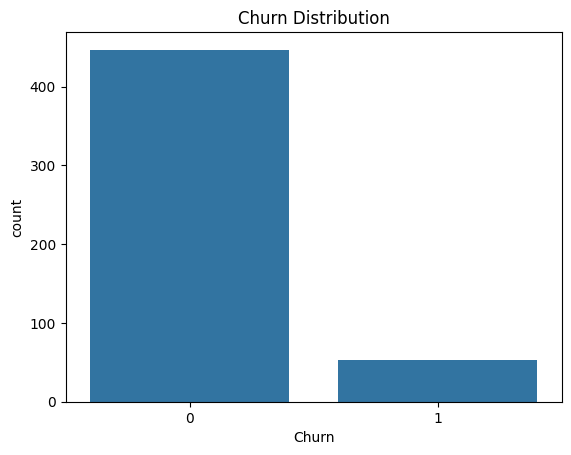

In [14]:
sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()

In [16]:
print(df.columns)

Index(['CustomerID', 'Tenure', 'MonthlyCharges', 'TotalCharges', 'Contract',
       'PaymentMethod', 'PaperlessBilling', 'SeniorCitizen', 'Churn'],
      dtype='str')


<Axes: >

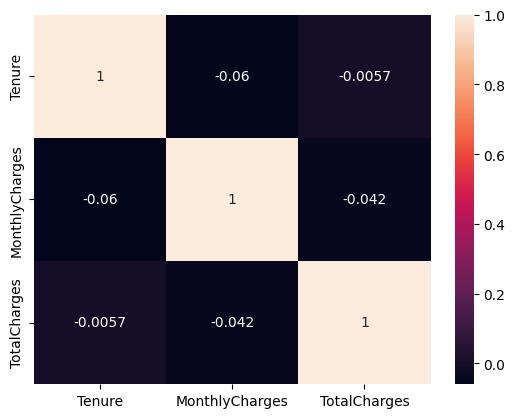

In [18]:
sns.heatmap(df[['Tenure','MonthlyCharges','TotalCharges']].corr(), annot=True)

In [21]:
print(df.columns)


Index(['CustomerID', 'Tenure', 'MonthlyCharges', 'TotalCharges', 'Contract',
       'PaymentMethod', 'PaperlessBilling', 'SeniorCitizen', 'Churn'],
      dtype='str')


In [23]:
print(df.columns.tolist())

['CustomerID', 'Tenure', 'MonthlyCharges', 'TotalCharges', 'Contract', 'PaymentMethod', 'PaperlessBilling', 'SeniorCitizen', 'Churn']


In [24]:
df.columns = df.columns.str.strip().str.lower()
print(df.columns)

Index(['customerid', 'tenure', 'monthlycharges', 'totalcharges', 'contract',
       'paymentmethod', 'paperlessbilling', 'seniorcitizen', 'churn'],
      dtype='str')


In [28]:
df.select_dtypes(include=['number']).columns

Index(['tenure', 'monthlycharges', 'totalcharges', 'seniorcitizen', 'churn'], dtype='str')

In [29]:
num_cols = df.select_dtypes(include=['number']).columns

X = df[num_cols[:-1]]   # all except last
y = df[num_cols[-1]]    # last column

from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X, y)

print("R2 Score:", model.score(X, y))

R2 Score: 0.26618916275303584


In [30]:
print(df.columns.tolist())

['customerid', 'tenure', 'monthlycharges', 'totalcharges', 'contract', 'paymentmethod', 'paperlessbilling', 'seniorcitizen', 'churn']


In [31]:
df.columns = df.columns.str.strip().str.lower()

# convert totalcharges to numeric
df['totalcharges'] = pd.to_numeric(df['totalcharges'], errors='coerce')

# drop missing values
df = df.dropna()

In [32]:
from sklearn.linear_model import LinearRegression

# Features (input)
X = df[['tenure','monthlycharges']]

# Target (output)
y = df['totalcharges']

# Model
model = LinearRegression()
model.fit(X, y)

# Score
print("R2 Score:", model.score(X, y))

R2 Score: 0.0018550319992883813


In [33]:
df['predicted_totalcharges'] = model.predict(X)
df.head()

,customerid,tenure,monthlycharges,totalcharges,contract,paymentmethod,paperlessbilling,seniorcitizen,churn,predicted_totalcharges
0,C00001,6,64,1540,One year,Credit Card,No,1,0,4358.010948
1,C00002,21,113,1753,Month-to-month,Electronic Check,Yes,1,0,4253.048645
2,C00003,27,31,1455,Two year,Credit Card,No,1,0,4400.706587
3,C00004,53,29,7150,Month-to-month,Electronic Check,No,1,0,4381.038525
4,C00005,16,185,1023,One year,Electronic Check,No,1,0,4123.156293


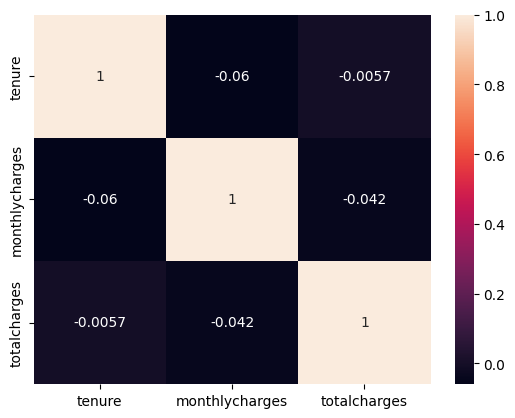

In [34]:
sns.heatmap(df[['tenure','monthlycharges','totalcharges']].corr(), annot=True)
plt.show()

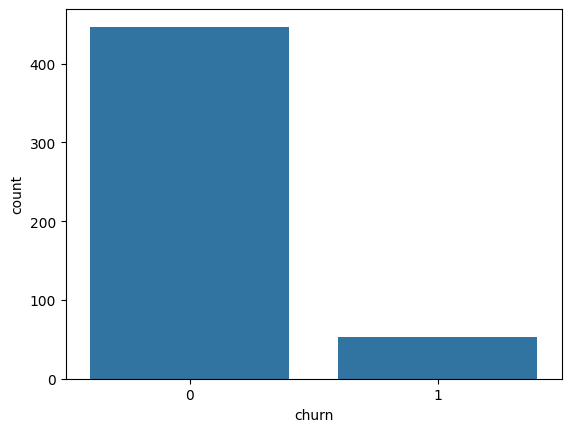

In [35]:
sns.countplot(x='churn', data=df)
plt.show()

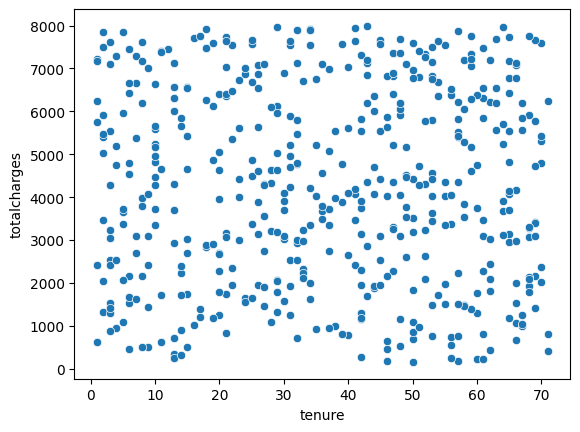

In [36]:
sns.scatterplot(x='tenure', y='totalcharges', data=df)
plt.show()

In [37]:
df.to_csv("predictions.csv", index=False)

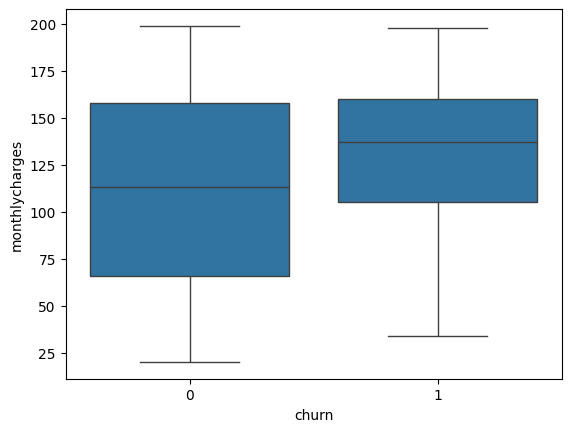

In [38]:
sns.boxplot(x='churn', y='monthlycharges', data=df)
plt.show()

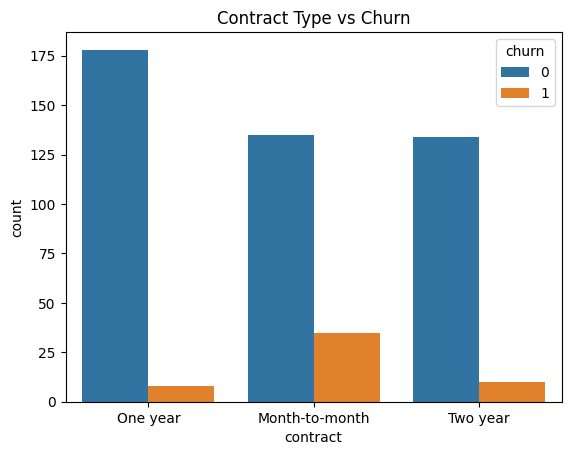

In [39]:
sns.countplot(x='contract', hue='churn', data=df)
plt.title("Contract Type vs Churn")
plt.show()

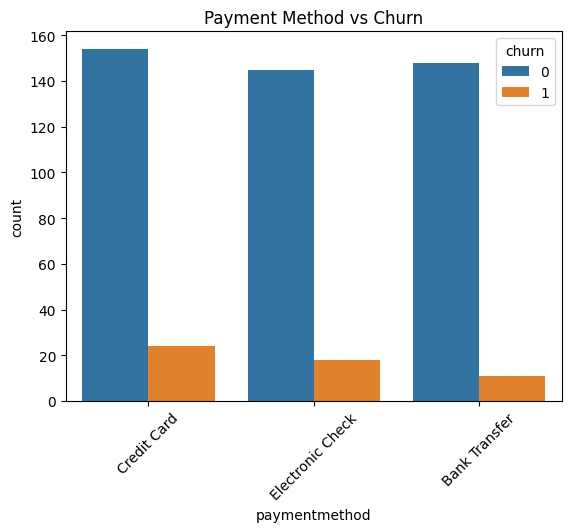

In [40]:
sns.countplot(x='paymentmethod', hue='churn', data=df)
plt.xticks(rotation=45)
plt.title("Payment Method vs Churn")
plt.show()

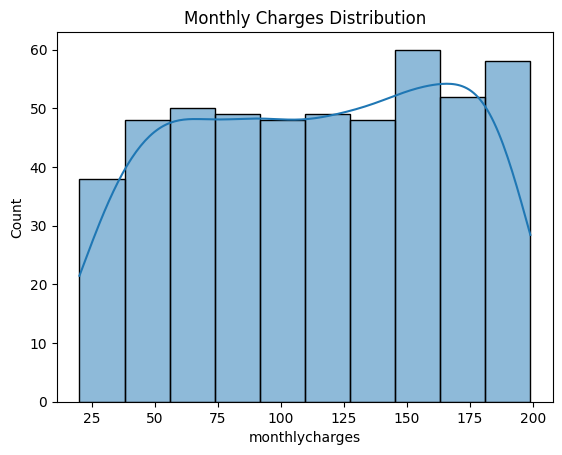

In [41]:
sns.histplot(df['monthlycharges'], kde=True)
plt.title("Monthly Charges Distribution")
plt.show()